# ==============================================================================
# INCISO (A)
# ==============================================================================

**1. Pico de Bragg:**
La curva $D(z)$ para iones pesados presenta una meseta inicial de baja deposición, seguida de un aumento abrupto y estrecho (el pico de Bragg) justo antes de que la partícula se detenga, y finaliza con una caída a cero casi instantánea. 
Físicamente, esto ocurre porque la probabilidad de interacción es inversamente proporcional al cuadrado de la velocidad ($\propto 1/v^2$) y como a medida que el protón penetra el tejido se va frenando, por lo que al alcanzar el final del recorrido, su velocidad decae rápidamente, lo que dispara exponencialmente la tasa de colisiones depositando la mayor parte de su energía cinética en un diferencial espacial muy reducido.

**2. Ecuación de Bethe-Bloch:**
Describe la pérdida de energía media por unidad de longitud $(-dE/dx)$ debido a ionización y excitación.
Donde: 
* **$K$**: Constante que agrupa valores fundamentales ($4\pi N_A r_e^2 m_e c^2$)
* **$z$**: Número de carga del proyectil (para protón $z=1$). El factor $z^2$ surge porque la fuerza de interacción electromagnética es directamente proporcional a la carga del proyectil, y la energía transferida depende del cuadrado de la fuerza.
* **$Z, A$**: Número atómico y número másico del medio absorbente.
* **$\beta$**: Velocidad relativa $v/c$. El factor $1/\beta^2$ indica que a menor velocidad, mayor es el tiempo que el campo eléctrico del proyectil interactúa con el electrón atómico, aumentando la transferencia de momento.
* **$\gamma$**: Factor de Lorentz $(1-\beta^2)^{-1/2}$.
* **$m_e c^2$**: Energía en reposo del electrón (0.511 MeV).
* **$T_{max}$**: Máxima energía cinética transferible a un electrón libre en una colisión.
* **$I$**: Potencial medio de excitación del medio (75 eV para agua).

**3. Energy Straggling:**
Dado que la pérdida de energía es el resultado de un número discreto de colisiones cuánticas independientes, la energía transferida en un paso $\Delta x$ es una variable aleatoria. Por el Teorema del Límite Central, para un número alto de colisiones, la distribución de pérdida de energía se aproxima a una Gaussiana de varianza:
$$\sigma_E^2 = 4\pi r_e^2 (m_e c^2)^2 N_e \frac{z^2}{\beta^2} \Delta x$$
donde $N_e$ es la densidad electrónica del medio y $r_e$ es el radio clásico del electrón. Esta fluctuación estocástica causa que protones idénticos se detengan a profundidades ligeramente diferentes.

**4. Dispersión Coulombiana Múltiple:**
Además de frenarse, los protones sufren pequeñas deflexiones angulares al interactuar con el campo eléctrico del *núcleo* atómico (dispersión elástica). Tras múltiples dispersiones en un espesor $\Delta x$, el ángulo total acumulado sigue una distribución aproximadamente gaussiana con un ángulo RMS dado por:
$$\theta_0 = \frac{13.6 \text{ MeV}}{\beta c p} z \sqrt{\frac{\Delta x}{X_0}} [1 + 0.038 \ln(\Delta x/X_0)]$$
donde $p$ es el momentum del proyectil y $X_0$ es la longitud de radiación del medio. Esta desviación lateral ensancha transversalmente el haz de protones a medida que penetra el material.

In [2]:
#b implementamos el modelo de Bethe-Bloch para calcular el rango CSDA de protones en agua, usando unidades SI y comparando con datos de PSTAR.
#  definimos las constantes físicas fundamentales, propiedades del agua y funciones para calcular beta, gamma, T_max, poder de frenado y rango CSDA.
#  Aunque parezcan muchas funciones siento que así es más simple luego corregir errores que colocar todo dentro de una sola función e integrar, sobre todo por la cantidad
#  de términos que tiene la ecuación
import numpy as np
from scipy.integrate import quad

# Constantes físicas fundamentales en el Sistema Internacional (SI)
c = 299792458.0              
m_e = 9.1093837e-31            
m_p = 1.67262192e-27             
Q = 1.602176634e-19        
mu_0 = 8.85418781e-12      
Na = 6.02214076e23          

# Derivamos las constantes compuestas necesarias para Bethe-Bloch
radio_e = (Q**2) / (4.0 * np.pi * mu_0 * m_e * (c**2))
K = 4.0 * np.pi * Na * (radio_e**2) * m_e * (c**2)
z_carga = 1.0                            # El protón tiene carga +1e

# Propiedades del agua en unidades SI
Z_agua = 10.0                            # Electrones por molécula
A_agua = 0.018015                        # Masa molar en kg/mol (no en g/mol)
densidad_agua = 1000.0                   # Densidad en kg/m^3
potencial_excitacion_agua = 75.0 * Q  # 75 eV pasados a Joules (J)

# esta funcion calcula beta, gamma y beta^2 a partir de la energía cinética
def calcular_beta_gamma(energia_cinetica_J):

    energia_reposo_proton = m_p * (c**2)
    gamma = 1.0 + (energia_cinetica_J / energia_reposo_proton)
    beta_cuadrado = 1.0 - (1.0 / (gamma**2))

    return np.sqrt(beta_cuadrado), gamma, beta_cuadrado

#Tope cinemático: el pencazo máximo de energía que el protón le puede transferir a un electrón libre
def calcular_T_max(beta_cuadrado, gamma):

    ratio_masas = m_e / m_p
    energia_reposo_electron = m_e * (c**2)
    numerador = 2.0 * energia_reposo_electron * beta_cuadrado * (gamma**2)
    denominador = 1.0 + 2.0 * gamma * ratio_masas + (ratio_masas**2)

    return numerador / denominador

# esta función implementa la ecuación de Bethe-Bloch para calcular el poder de frenado másico en J m^2 / kg, y luego lo multiplica por la densidad del agua para obtener el poder de frenado lineal en J/m.
def poder_frenado_bethe_bloch(energia_cinetica_J):

    energia_corte_J = 0.1 * 1e6 * Q

    # A energías muy bajas el protón empieza a capturar electrones y la teoría colapsa.
    # Metemos un corte a machete en 0.1 MeV para que la integral no reviente por singularidades.
    if energia_cinetica_J < energia_corte_J: 
        return 1e15 
    
    _, gamma, beta_cuadrado = calcular_beta_gamma(energia_cinetica_J)
    t_max = calcular_T_max(beta_cuadrado, gamma)
    
    energia_reposo_electron = m_e * (c**2)

    #factor que multiplica por fuera
    coeficiente = K * (z_carga**2) * (Z_agua / A_agua) * (1.0 / beta_cuadrado)
    
    # Argumento del logaritmo natural
    argumento_ln = (2.0 * energia_reposo_electron * beta_cuadrado * (gamma**2) * t_max) / (potencial_excitacion_agua**2)
    termino_ln = np.log(argumento_ln)
    
    # Poder de frenado másico en J m^2 / kg
    poder_masico = coeficiente * (0.5 * termino_ln - beta_cuadrado)
    
    # Al multiplicar por la densidad (kg/m^3), obtenemos el frenado lineal en J/m
    return poder_masico * densidad_agua 

# esta función da vuelta lo anterior para poder integrar en términos de energía cinética y obtener el rango CSDA
def inversa_poder_frenado(energia_cinetica_J):
    
    return 1.0 / poder_frenado_bethe_bloch(energia_cinetica_J)

# esta función nos devuelve el rango CSDA en centímetros para una energía "energía_Mev" en MeV que son justamente las unidades de los datos
# de PSTAR
def calcular_rango_csda(energia_MeV):

    energia_J = energia_MeV * 1e6 * Q
    energia_min_J = 0.1 * 1e6 * Q
    
    # La integral nos da el rango directamente en metros
    rango_metros, _ = quad(inversa_poder_frenado, energia_min_J, energia_J, limit=1000)
    
    return rango_metros * 100.0  # Retorno final en cm

# Extraje directamente los 3 pares de datos que pedian para simplificar el código (en vez de extraer todo un txt de varios valores) estos
# estan en (MeV, cm)
datos_pstar = {
    50.0: 2.227,
    150.0: 15.77,
    250.0: 37.94
}

print("Cálculo de Rango CSDA en Agua: Bethe-Bloch (SI) vs PSTAR")
print("=" * 70)
print(f"{'Energía (MeV)':<15} | {'R_CSDA Teórico (cm)':<22} | {'R_CSDA PSTAR (cm)':<20}")
print("-" * 70)

for energia_test, rango_pstar in datos_pstar.items():
    rango_teorico = calcular_rango_csda(energia_test)
    error_relativo = abs(rango_teorico - rango_pstar) / rango_pstar * 100.0
    print(f"{energia_test:<15.1f} | {rango_teorico:<22.4f} | {rango_pstar:<10.4f} ({error_relativo:.2f}% err)")

Cálculo de Rango CSDA en Agua: Bethe-Bloch (SI) vs PSTAR
Energía (MeV)   | R_CSDA Teórico (cm)    | R_CSDA PSTAR (cm)   
----------------------------------------------------------------------
50.0            | 2.2220                 | 2.2270     (0.23% err)
150.0           | 15.7671                | 15.7700    (0.02% err)
250.0           | 37.9310                | 37.9400    (0.02% err)


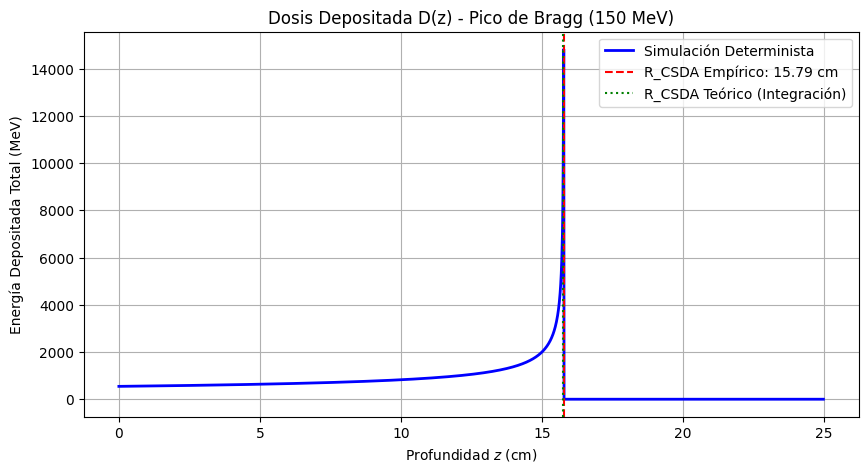

Se obtuvo un error de 0.1454%


In [7]:
# c- 
import matplotlib.pyplot as plt
# inicializamos las variables en SI 
N_protones = 10000
energia_inicial_MeV = 150.0
energia_inicial_J = energia_inicial_MeV * 1e6 * Q
dx_m = 0.1 * 1e-3

# Armamos el dominio espacial hasta 25 cm (0.25 m) 
z_bins_m = np.arange(0, 0.25, dx_m)
dosis_determinista_J = np.zeros(len(z_bins_m))

# Como acá no hay aleatoriedad, todos los protones hacen el mismo trayecto calcado.
# Simulamos un solo protón y al final multiplicamos la dosis depositada por N_protones 
energia_actual_J = energia_inicial_J
indice_z = 0
energia_corte_J = 0.1 * 1e6 * Q

while energia_actual_J > energia_corte_J and indice_z < len(z_bins_m) - 1:
    # Calculamos el poder de frenado y lo multiplicamos por el pasito espacial
    # Esto nos da la pérdida media de energía en este diferencial
    dE_dx = poder_frenado_bethe_bloch(energia_actual_J)
    perdida_energia_J = dE_dx * dx_m
    
    #el proton esta limitado energéticamente, no puede perder más energía de la que le queda
    if perdida_energia_J > energia_actual_J:
        perdida_energia_J = energia_actual_J
        
    # Acumulamos la dosis en este segmento de agua
    dosis_determinista_J[indice_z] += perdida_energia_J * N_protones
    
    energia_actual_J -= perdida_energia_J
    indice_z += 1

rango_empirico_m = z_bins_m[indice_z]

# Convertimos los datos de vuelta a cm y MeV para que el gráfico sea comparable con los resultados anteriores
z_bins_cm = z_bins_m * 100.0
dosis_determinista_MeV = dosis_determinista_J / (1e6 * Q)
rango_empirico_cm = rango_empirico_m * 100.0

plt.figure(figsize=(10, 5))
plt.plot(z_bins_cm, dosis_determinista_MeV, lw=2, color='blue', label='Simulación Determinista')
plt.axvline(rango_empirico_cm, color='red', linestyle='--', label=f'R_CSDA Empírico: {rango_empirico_cm:.2f} cm')
plt.axvline(calcular_rango_csda(energia_inicial_MeV), color='green', linestyle=':', label='R_CSDA Teórico (Integración)')

plt.xlabel('Profundidad $z$ (cm)')
plt.ylabel('Energía Depositada Total (MeV)')
plt.title('Dosis Depositada D(z) - Pico de Bragg (150 MeV)')
plt.legend()
plt.grid(True)
plt.show()

error_emp_teo = abs(rango_empirico_cm - calcular_rango_csda(energia_inicial_MeV))/calcular_rango_csda(energia_inicial_MeV)
print (f"Se obtuvo un error de {(error_emp_teo)*100:.4f}%")

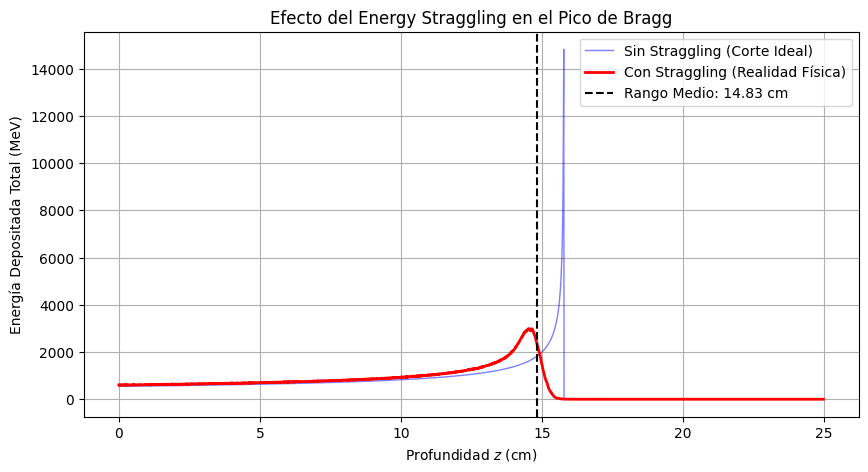

Ensanchamiento longitudinal del pico (sigma_R): 0.2904 cm


In [ ]:
#d- 

# Sacamos la densidad electrónica del agua en electrones por metro cúbico
densidad_electronica = (Z_agua / A_agua) * Na * densidad_agua 
energia_reposo_electron_J = m_e * (c**2)

# Este armatoste de constantes corresponde a la primera parte de la varianza de Bohr
constante_straggling = 4.0 * np.pi * (radio_e**2) * (energia_reposo_electron_J**2) * densidad_electronica

dosis_estocastica_J = np.zeros(len(z_bins_m))
rangos_finales_m = []

# Como hay aleatoriedad debemmos integrar protón por protón a diferencia de antes.
for p in range(N_protones):
    energia_actual_J = energia_inicial_J
    indice_z = 0
    
    while energia_actual_J > energia_corte_J and indice_z < len(z_bins_m) - 1:
        # mismo ciclo que antes
        perdida_media_J = poder_frenado_bethe_bloch(energia_actual_J) * dx_m
        
        # Extraemos el beta^2 cinemático para colocarlo en la ecuación de Bohr
        _, _, beta_cuadrado = calcular_beta_gamma(energia_actual_J)
        
        # Calculamos la varianza de la fluctuación y le sacamos la raíz para la desviación estándar
        varianza_energia = (constante_straggling * (z_carga**2)  * dx_m) / beta_cuadrado
        desviacion_estandar_J = np.sqrt(varianza_energia)
        
        # Muestreamos la pérdida real desde una dist normal
        perdida_real_J = np.random.normal(perdida_media_J, desviacion_estandar_J)
        
        # definimos dentro de los parámetros la perdida real de energía en casa paso para los protones
        perdida_real_J = max(0.0, min(perdida_real_J, energia_actual_J))
        
        dosis_estocastica_J[indice_z] += perdida_real_J
        energia_actual_J -= perdida_real_J
        indice_z += 1
        
    # Anotamos en qué coordenada exacta (en metros) se detuvo este protón particular
    rangos_finales_m.append(z_bins_m[indice_z])

# Computamos el ensanchamiento estocástico del pico (desviación estándar espacial)
rangos_finales_cm = np.array(rangos_finales_m) * 100.0
sigma_R_cm = np.std(rangos_finales_cm)
rango_medio_cm = np.mean(rangos_finales_cm)

# Convertimos la dosis estocástica de Joules a MeV
dosis_estocastica_MeV = dosis_estocastica_J / (1e6 * Q)

plt.figure(figsize=(10, 5))
plt.plot(z_bins_cm, dosis_determinista_MeV, lw=1, color='blue', alpha=0.5, label='Sin Straggling (Corte Ideal)')
plt.plot(z_bins_cm, dosis_estocastica_MeV, lw=2, color='red', label='Con Straggling (Realidad Física)')
plt.axvline(rango_medio_cm, color='black', linestyle='--', label=f'Rango Medio: {rango_medio_cm:.2f} cm')

plt.xlabel('Profundidad $z$ (cm)')
plt.ylabel('Energía Depositada Total (MeV)')
plt.title('Efecto del Energy Straggling en el Pico de Bragg')
plt.legend()
plt.grid(True)
plt.show()

print(f"Ensanchamiento longitudinal del pico (sigma_R): {sigma_R_cm:.4f} cm")

# Este ensanchamiento elimina la nitidez del borde distal de irradiación. Clínicamente, esto obliga al radioterapeuta a agregar márgenes de seguridad en 
# la planificación para garantizar la cobertura total del tumor, lo que inevitablemente expone a una dosis no deseada al tejido sano u órganos de riesgo situados inmediatamente detrás.